## Enrichment data combined to NNCARs calculation tools

We want to look at experimental values in order to predict enrichment, and
therefore more effective extrusion, from different metrics:
- NRLs
- fuzziness
- N_nuc
- density

The pipeline uses 3 different files:
- GSM4577764_Mcd1p_WT.bigwig : Enrichment in Cohesin (ChIP-seq)
- danpos.s2.xls               : Enrichment in Nucleosomes
- AD908_G2_mixed.mcool         : Hi-C map

From GSM4577764_Mcd1p_WT.bigwig:
- We get enrichment in cohesin
- We can therefore identify CARs (peaks) and build NN CARs pairs

From danpos.s2.xls:
- We get enrichment in nucleosomes
- We get smt_pos / smt_value / fuzziness_score
- We can therefore link these values to the cohesin enrichment (NRL,
  fuzziness, N_nuc, density per NN CARs pair)

From AD908_G2_mixed.mcool:
- We get an Hi-C map, i.e. the observed number of contacts between loci [i,j]
- We also compute, for each genomic distance, the expected number of
  contacts under a null model with no specific 3D structure (the P(s) decay,
  via cooltools.expected_cis) — this captures the trivial polymer effect
  where nearby loci contact more often regardless of any loop
- We can therefore compute observed/expected at the CAR1-CAR2 pixel, i.e.
  the loop intensity between NN CARs, decoupled from genomic distance

## Calculating CARs_NN via cohesin enrichments

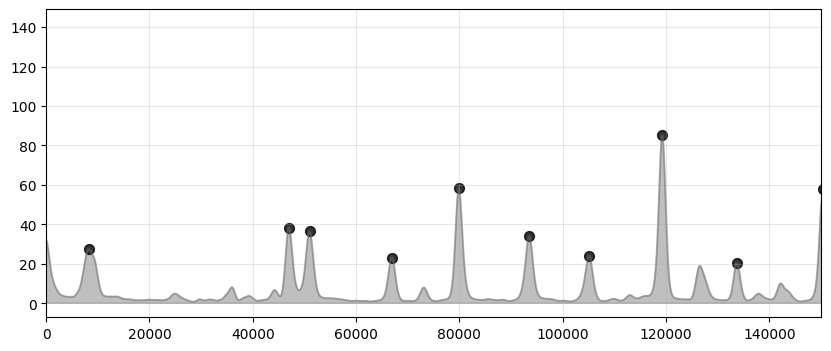

In [1]:
# Analyzing Cohesin Peaks in Yeast Genome
# This script :
#   - reads a bigwig file containing cohesin enrichment data
#   - smooths the data 
#   - identifies peaks
#   - visualizes the results


# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bio
import bioframe
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d


# ── Global Values ──────────────────────────────────────────────────────────────────

# Chromosomes
CHROMS = [
    'chrI',
    'chrII',
    'chrIII',
    'chrIV',
    'chrV',
    'chrVI',
    'chrVII',
    'chrVIII',
    'chrIX',
    'chrX',
    'chrXI',
    'chrXII',
    'chrXIII',
    'chrXIV',
    'chrXV',
    'chrXVI'
]

# Cohesin :
DATA_COHE = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/GSM4577764_Mcd1p_WT.bigwig"


# ── Window ──────────────────────────────────────────────────────────────────

# Reading Data:
data = DATA_COHE

# Choosing the region of reads
chrom   = 'chrII'
df1     = bioframe.read_bigwig(data, chrom)
SIGMA   = 500


# ── Calculations ──────────────────────────────────────────────────────────────────

# Note that bins have different sizes, in this case I interploate but you may also rebin to the scale is meaningful for your simulations
pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
enrichment = df1['value'].values

# Regular grid (1 bp spacing here)
pos_uniform = np.arange(pos.min(), pos.max()+1)

# Interpolate
f = interp1d(pos, enrichment,
             kind='linear',
             bounds_error=False,
             fill_value='extrapolate')
enrichment_uniform = f(pos_uniform)

# Smoothing -> sigma is the smooting parameter
# Based on the biological value : typically, beatween each car there is between 10 and 20 kb
enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=SIGMA)

# Finding Peaks using Scipy
# With a minimum height of min_h and a minimum distance of min_d between peaks
min_h = 20
min_d = 10
prominence = 0.050
peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)


# ── Plot ──────────────────────────────────────────────────────────────────

xlims = [0, 150_000]
plt.figure(figsize=(10, 4))
plt.plot(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.fill_between(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.scatter(pos_uniform[peaks], enrichment_smooth[peaks], color="black", s=50, alpha=0.8)
plt.xlim(xlims)
plt.grid(True, which="both", alpha=0.30)
plt.show()

In [2]:
# From the previoues plot, we can see that the peaks are well detected. 
# We can now create a dataframe with the determined values upper.
# The previoues dataframe will be used to create a new dataframe 
# with the nearest neighbor CARs for each chromosome.


# ── Calculating File ──────────────────────────────────────────────────────────────────

# Create a dataframe with the peaks heights and positions
df_CARs = []
for chrom in CHROMS[:]:
    df1 = bioframe.read_bigwig(data, chrom)
    pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
    enrichment = df1['value'].values
    pos_uniform = np.arange(pos.min(), pos.max()+1)
    f = interp1d(pos, enrichment,
                 kind='linear',
                 bounds_error=False,
                 fill_value='extrapolate')
    enrichment_uniform = f(pos_uniform)
    enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=SIGMA)
    peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
    chrom_df = pd.DataFrame({'chrom': chrom, 'start': pos_uniform[peaks], 'end': pos_uniform[peaks], 'CAR strength': enrichment_smooth[peaks]})
    df_CARs.append(chrom_df)
df_CARs = pd.concat(df_CARs, ignore_index=True)

# Condition on the detection of CARs !
CAR_strenght = 10

# Create df for cooltools off-diagonal plots using only NN CARS
df_CARs_NN=[]
for chrom in CHROMS[:]:
    df_CARs_NN_chrom =pd.DataFrame(columns=['chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2'])
    chrom_mask = (df_CARs["chrom"] == chrom) & (df_CARs["CAR strength"] > CAR_strenght)

    df_CARs_NN_chrom["chrom1"]=list(df_CARs[chrom_mask][:-1]["chrom"])
    df_CARs_NN_chrom["chrom2"]=list(df_CARs[chrom_mask][1:]["chrom"])

    df_CARs_NN_chrom["start1"]=list(df_CARs[chrom_mask][:-1]["start"])
    df_CARs_NN_chrom["start2"]=list(df_CARs[chrom_mask][1:]["start"]) 

    df_CARs_NN_chrom["end1"]=list(df_CARs[chrom_mask][:-1]["end"])
    df_CARs_NN_chrom["end2"]=list(df_CARs[chrom_mask][1:]["end"])

    df_CARs_NN_chrom["CAR strength1"]=list(df_CARs[chrom_mask][:-1]["CAR strength"])
    df_CARs_NN_chrom["CAR strength2"]=list(df_CARs[chrom_mask][1:]["CAR strength"])

    df_CARs_NN.append(df_CARs_NN_chrom)
    
df_CARs_NN = pd.concat(df_CARs_NN, ignore_index=True)


# ── Saving File ──────────────────────────────────────────────────────────────────
df_CARs_NN.to_parquet("df_CARs_NN.parquet", index=False)
print(df_CARs_NN.head())

  chrom1    start1      end1  CAR strength1 chrom2    start2      end2  \
0   chrI   51741.0   51741.0     111.591820   chrI   65253.0   65253.0   
1   chrI   65253.0   65253.0      35.773094   chrI   80364.0   80364.0   
2   chrI   80364.0   80364.0      94.203125   chrI   95296.0   95296.0   
3   chrI   95296.0   95296.0      52.778685   chrI  127193.0  127193.0   
4   chrI  127193.0  127193.0      43.285847   chrI  134169.0  134169.0   

   CAR strength2  
0      35.773094  
1      94.203125  
2      52.778685  
3      43.285847  
4      69.071751  


## Analyzing CARs_nn and Nucleosome profiles in parallel

In [4]:
# Now that we have the NNCARs file giving the interaction between NNRCARs
# We can use this file in common with the ATACseq / CHIPseq / Enrichment data
# From this data we extract for each pair of NNCARs:
#   - Nucleosome Repeat Length (NRL)    - and median
#   - Median fuzziness score            - and median
#   - smt_value                         - and median
#   - smt_density                       - and median
#   - genomic_distance                  - and median


# ── Imports ──────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import polars as pl
import pyBigWig


# ── 1. Reading Data ──────────────────────────────────────────────────────────

# CARs (Couples of Nearest Neighbor CARs):
# 1 line = 1 couple = 
# - chrom1
# - start1
# - end1
# - chrom2
# - start2
# - end2
df_CARs_NN = pl.read_parquet("df_CARs_NN.parquet")

# There are some CARS that have a strenght that are too strong
# Thats why I will filter the dataframe to keep only the CARs that have a strenght lower than threshold.
threshold = 100
df_CARs_NN = df_CARs_NN.filter(pl.col("CAR strength1") < threshold)

# NUCLEOSOMES (enrichment data (mono-nucleosome midpoints) from DANPOS2):
# EAch point is 
# - an enrichment value (smt_value) -> Float64
# - at a given position (smt_pos) -> Float64
# - with a fuzziness score (fuzziness_score) -> Float64
NUC_PATH = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
df_NUCLEOSOMES = pl.read_csv(NUC_PATH, separator="\t").with_columns(
    pl.col("smt_pos").cast(pl.Float64),
    pl.col("smt_value").cast(pl.Float64),
    pl.col("fuzziness_score").cast(pl.Float64),
)


# ── 2. Adding an identifier per line ─────────────────────────────────────

if "car_idx" not in df_CARs_NN.columns:
    df_CARs_NN = df_CARs_NN.with_row_index("car_idx")

df_CARs_NN = df_CARs_NN.with_columns(
    pl.col("start1").cast(pl.Float64),
    pl.col("start2").cast(pl.Float64),
)
 

# ── 3. Associating both files ────────────────────────────────────────────

# A nucleosome is associated with a pair of CARs if its smt_pos falls
# strictly between start1 and start2, on the same chromosome.
 
cars = df_CARs_NN.select(["car_idx", "chrom1", "start1", "start2"])
 
nuc_in_car = cars.join_where(
    df_NUCLEOSOMES,
    pl.col("chr") == pl.col("chrom1"),
    pl.col("smt_pos") > pl.col("start1"),
    pl.col("smt_pos") < pl.col("start2"),
)
 
 
# ── 4. Aggregation by CAR: lists of positions/values + NRL ──────────
# NRL (Nucleosome Repeat Length) = successive differences between sorted smt_pos values.
 
nuc_per_car = (
    nuc_in_car
    .sort(["car_idx", "smt_pos"])
    .group_by("car_idx", maintain_order=True)
    .agg(
        pl.col("smt_pos"),
        pl.col("smt_value"),
        pl.col("fuzziness_score"),
        pl.col("smt_pos").diff().slice(1).alias("NRLs"),
    )
)

# Merge with the CARs table (left join: CARs without an associated nucleosome
# will have empty lists after the `fill_null` function below)
df_CARs_NUCLEO = (
    df_CARs_NN
    .join(nuc_per_car, on="car_idx", how="left")
    .with_columns(
        pl.col("smt_pos").fill_null([]),
        pl.col("smt_value").fill_null([]),
        pl.col("fuzziness_score").fill_null([]),
        pl.col("NRLs").fill_null([]),
    )
)
 
 
# ── 5. Adding Summary Columns ─────────────────────────────────────────
 
df_CARs_NUCLEO = df_CARs_NUCLEO.with_columns(
    pl.col("NRLs").list.median().alias("NRLs_median"),
    pl.col("fuzziness_score").list.median().alias("fuzziness_median"),
    pl.col("smt_value").list.median().alias("smt_median"),
    pl.col("smt_value").list.len().alias("N_nuc"),
    (pl.col("smt_value").list.sum() / (pl.col("start2") - pl.col("start1")))
        .alias("smt_density"),
)
 
 
# ── 6. Genomic distance between CAR1 and CAR2 ────────────────────────────
# CARs are point-like (start == end), so the distance between the two
# CARs in an NN pair is simply start2 - start1.
 
df_CARs_NUCLEO = df_CARs_NUCLEO.with_columns(
    (pl.col("start2") - pl.col("start1")).alias("genomic_distance")
)
 
 
# ── 7. Average cohesin signal ±1 kb around each CAR ──────────────────
# Signal = cohesin (Mcd1p, DATA_COHE), the same signal as that used to
# detect CARs. We calculate the average signal around CAR1 and CAR2,
# then take the average of the two for each pair.
 
FLANK_SIGNAL = 1_000  # ± 1 kb
 
def mean_signal(bw: pyBigWig.pyBigWig, chrom: str, center: float, flank: int = FLANK_SIGNAL) -> float:
    """Moyenne du signal bigwig dans la fenêtre [center-flank, center+flank]."""
    if chrom not in bw.chroms():
        return np.nan
    chrom_len = bw.chroms(chrom)
    start = max(0, int(center) - flank)
    end = min(chrom_len, int(center) + flank)
    if end <= start:
        return np.nan
    val = bw.stats(chrom, start, end, type="mean")[0]
    return np.nan if val is None else val
 
with pyBigWig.open(DATA_COHE) as bw:
    pdf = df_CARs_NUCLEO.to_pandas()
    pdf["cohesin_signal1"] = [
        mean_signal(bw, c, p) for c, p in zip(pdf["chrom1"], pdf["start1"])
    ]
    pdf["cohesin_signal2"] = [
        mean_signal(bw, c, p) for c, p in zip(pdf["chrom2"], pdf["start2"])
    ]
    pdf["cohesin_signal_mean"] = pdf[["cohesin_signal1", "cohesin_signal2"]].mean(axis=1)
 
df_CARs_NUCLEO = pl.from_pandas(pdf)
 
 
# ── 8. Writing Results ────────────────────────────────────────────────────

print("df_cars_NUCLEO columns:", df_CARs_NUCLEO.columns)
print("df_cars_NUCLEO columns type:", df_CARs_NUCLEO.dtypes)
print(df_CARs_NUCLEO)
df_CARs_NUCLEO.write_parquet("df_CARs_NUCLEO.parquet")

df_cars_NUCLEO columns: ['car_idx', 'chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2', 'smt_pos', 'smt_value', 'fuzziness_score', 'NRLs', 'NRLs_median', 'fuzziness_median', 'smt_median', 'N_nuc', 'smt_density', 'genomic_distance', 'cohesin_signal1', 'cohesin_signal2', 'cohesin_signal_mean']
df_cars_NUCLEO columns type: [UInt32, String, Float64, Float64, Float64, String, Float64, Float64, Float64, List(Float64), List(Float64), List(Float64), List(Float64), Float64, Float64, Float64, UInt32, Float64, Float64, Float64, Float64, Float64]
shape: (800, 22)
┌─────────┬────────┬──────────┬──────────┬───┬─────────────┬─────────────┬────────────┬────────────┐
│ car_idx ┆ chrom1 ┆ start1   ┆ end1     ┆ … ┆ genomic_dis ┆ cohesin_sig ┆ cohesin_si ┆ cohesin_si │
│ ---     ┆ ---    ┆ ---      ┆ ---      ┆   ┆ tance       ┆ nal1        ┆ gnal2      ┆ gnal_mean  │
│ u32     ┆ str    ┆ f64      ┆ f64      ┆   ┆ ---         ┆ ---         ┆ ---        ┆ ---        │


# Analysing

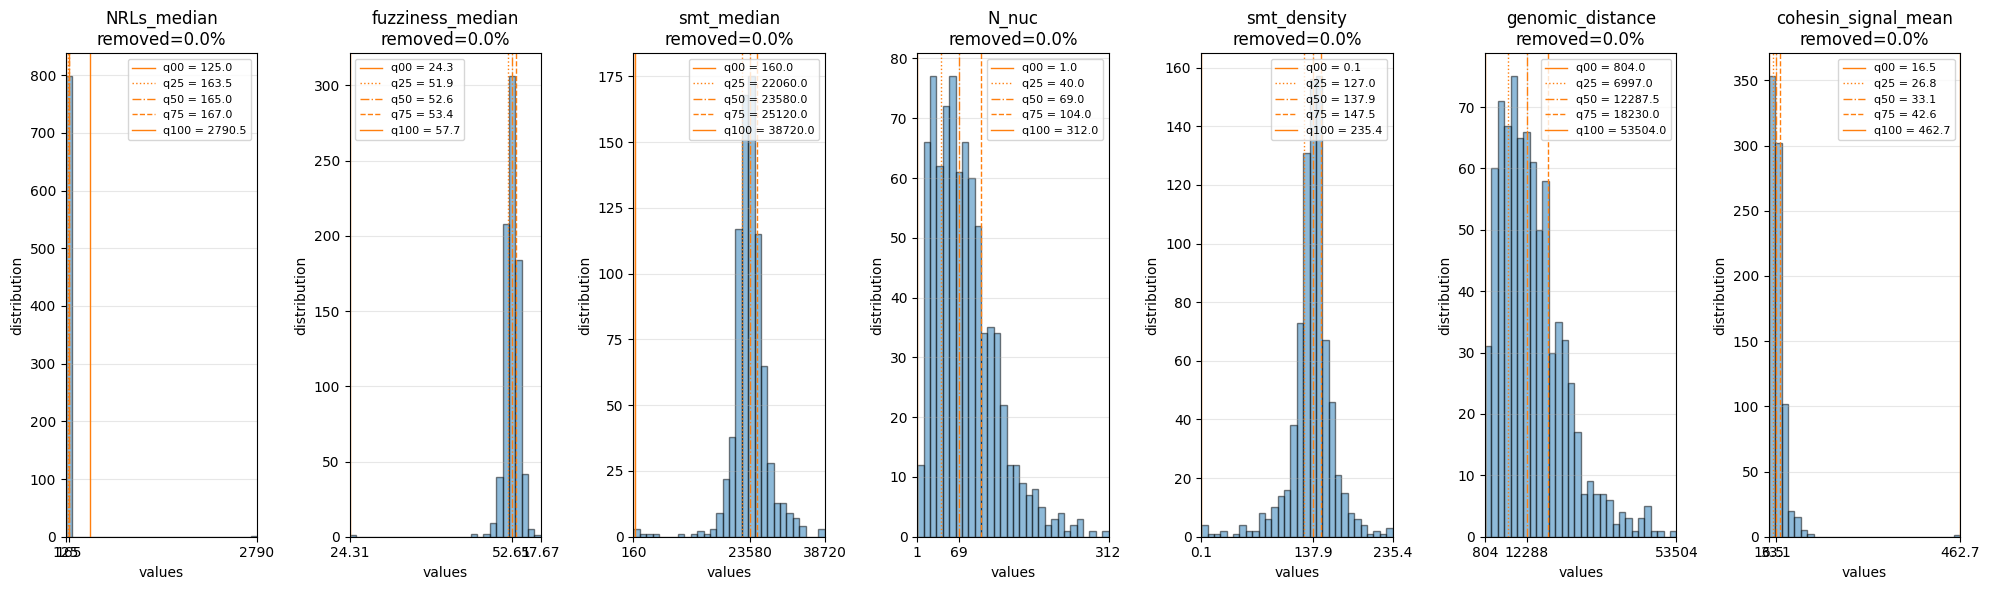

In [ ]:
# This cell creates a Parquet file containing each of the quartiles for each column of interest.
# Later the values with be fixed


# ── Imports ──────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import polars as pl


# ── DataFrame ──────────────────────────────────────────────────────────────────

df_CARs_NUCLEO = pl.read_parquet("df_CARs_NUCLEO.parquet")


# ── Prelimenary Analysis ──────────────────────────────────────────────────────

fig, axes = plt.subplots(figsize=(20, 6), ncols=7, nrows=1)

COLUMNS         = ["NRLs_median", "fuzziness_median", "smt_median", "N_nuc", "smt_density", "genomic_distance", "cohesin_signal_mean"]
dict_quartiles  = {"quartiles": [0.05, 0.25, 0.5, 0.75, 0.95]}
dict_quartiles.update({col: [] for col in COLUMNS})

for ax, col in zip(axes, COLUMNS):

    # Suppressing NaN / inf
    values = df_CARs_NUCLEO[col].to_numpy()
    values = values[np.isfinite(values)]

    # In order to get a better visualization
    q00, q25, q50, q75, q100 = np.percentile(
        values,
        [0, 25, 50, 75, 100]
    )
    values_plot = values[(values >= q00) & (values <= q100)]
    vmin, vmax = q00, q100
    n = len(values)
    n_removed = (n - len(values_plot)) / 100

    # Quartiles
    dict_quartiles[col] = np.array([q00, q25, q50, q75, q100], dtype=np.float64)
    ax.axvline(q00, color="tab:orange", linestyle="-", linewidth=1, label=f"q00 = {q00:.1f}")
    ax.axvline(q25, color="tab:orange", linestyle=":", linewidth=1, label=f"q25 = {q25:.1f}")
    ax.axvline(q50, color="tab:orange", linestyle="-.", linewidth=1, label=f"q50 = {q50:.1f}")
    ax.axvline(q75, color="tab:orange", linestyle="--", linewidth=1, label=f"q75 = {q75:.1f}")
    ax.axvline(q100, color="tab:orange", linestyle="-", linewidth=1, label=f"q100 = {q100:.1f}")

    # Histograms
    ax.hist(values_plot, bins=30, edgecolor="black", alpha=0.5)

    # Plots
    ax.set_xticks([vmin, q50, vmax])
    ax.set_xlim(vmin, vmax)
    ax.set_xlabel("values")
    ax.set_ylabel("distribution")
    ax.set_title(f"{col}\nremoved={n_removed}%")
    ax.grid(True, which="both", alpha=0.30)
    ax.legend(fontsize=8)

# Writing
df_quartiles = pl.DataFrame(dict_quartiles)
df_quartiles.write_parquet("df_quartiles.parquet")

# Saving
plt.tight_layout()
plt.savefig("histograms_total.png", dpi=300)
plt.show()

In [42]:
# ── Quartile Function ──────────────────────────────────────────────────────────────────

def change_quarters(
        df_quartiles: pl.DataFrame,
        key: str,
        values: np.ndarray,
    ) -> pl.DataFrame:
        """Change the quartiles to be used for each column of interest."""
        return df_quartiles.with_columns(
            pl.Series(key, values)
    )

# ── Imports ──────────────────────────────────────────────────────────────────

df_metric = df_quartiles.clone()

new_metric = {
    "NRLs_median":          np.array([160, 162.5, 165, 167.5, 170],         dtype=np.float64),
    "fuzziness_median":     np.array([50, 51, 52, 53, 54],              dtype=np.float64),
    "smt_median":           np.array([1.5e4, 2e4, 2.5e4, 3e4, 3.5e4],   dtype=np.float64),
    "N_nuc":                np.array([0, 75, 150, 225, 300],              dtype=np.float64),
    "smt_density":          np.array([60, 90, 120, 150, 180],           dtype=np.float64),
    "genomic_distance":     np.array([0, 1e4, 2e4, 3e4, 4e4],        dtype=np.float64),
    "cohesin_signal_mean":  np.array([10, 20, 30, 40, 50],              dtype=np.float64),
}

for key, values in new_metric.items():
    df_metric = change_quarters(
        df_quartiles=df_metric,
        key=key,
        values=values
    )

print(df_quartiles)
print(df_metric)

shape: (5, 8)
┌───────────┬────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┐
│ quartiles ┆ NRLs_media ┆ fuzziness_ ┆ smt_median ┆ N_nuc     ┆ smt_densi ┆ genomic_d ┆ cohesin_s │
│ ---       ┆ n          ┆ median     ┆ ---        ┆ ---       ┆ ty        ┆ istance   ┆ ignal_mea │
│ f64       ┆ ---        ┆ ---        ┆ f64        ┆ f64       ┆ ---       ┆ ---       ┆ n         │
│           ┆ f64        ┆ f64        ┆            ┆           ┆ f64       ┆ f64       ┆ ---       │
│           ┆            ┆            ┆            ┆           ┆           ┆           ┆ f64       │
╞═══════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0.05      ┆ 125.0      ┆ 24.305646  ┆ 160.0      ┆ 1.0       ┆ 0.054616  ┆ 804.0     ┆ 16.536678 │
│ 0.25      ┆ 163.5      ┆ 51.861959  ┆ 22060.0    ┆ 40.0      ┆ 126.95403 ┆ 6997.0    ┆ 26.781008 │
│           ┆            ┆            ┆            ┆           ┆ 2         ┆ 

## Hic Map over NNCARs

INFO:root:creating a Pool of 8 workers
INFO:coolpuppy:('chrI', 'chrI'): 8
INFO:coolpuppy:('chrIII', 'chrIII'): 17
INFO:coolpuppy:('chrVI', 'chrVI'): 16
INFO:coolpuppy:('chrIX', 'chrIX'): 32
INFO:coolpuppy:('chrII', 'chrII'): 49
INFO:coolpuppy:('chrV', 'chrV'): 28
INFO:coolpuppy:('chrVIII', 'chrVIII'): 31
INFO:coolpuppy:('chrXI', 'chrXI'): 35
INFO:coolpuppy:('chrVII', 'chrVII'): 61
INFO:coolpuppy:('chrX', 'chrX'): 47
INFO:coolpuppy:('chrXII', 'chrXII'): 61
INFO:coolpuppy:('chrXIV', 'chrXIV'): 48
INFO:coolpuppy:('chrXVI', 'chrXVI'): 59
INFO:coolpuppy:('chrXIII', 'chrXIII'): 56
INFO:coolpuppy:('chrXV', 'chrXV'): 66
INFO:coolpuppy:('chrIV', 'chrIV'): 93
INFO:coolpuppy:Total number of piled up windows: 707


<Axes: xlabel='relative position (kbp)'>

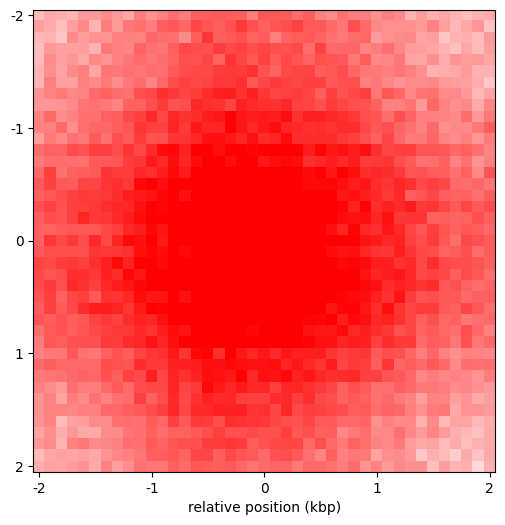

In [43]:
# Plotting an HiC map via NNCARs
# It plots the all signal of all NNCARs non sorted (Function based)
# Without any filter on NRLs / genomic_distance / fuzziness / ...


# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bio
import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Global Values ──────────────────────────────────────────────────────────────────

# Window size NB this is also the minimal distance between CARs that will be considered
# If you consider too many low strength CARs that may be a problem
PATH            = "/home/nicolas/Documents/Workspace/nucleo/"
RESOLUTION      = 100
FLANK           = 2000 

DF_CARS_NUCLEO  =  pd.read_parquet(
    PATH + "notebooks/cars/df_CARs_NUCLEO.parquet"
)

# Reading the OBSERVED contacts
CLR = cooler.Cooler(
    PATH +  f"outputs/NUC/AD908_G2_mixed.mcool::/resolutions/{RESOLUTION}"
)

VIEW_DF = pd.DataFrame({
    "chrom": CLR.chromnames,
    "start": 0,
    "end": CLR.chromsizes.values,
    "name": CLR.chromnames
})

# Calculating the EXPECTED contacts
# It calculates the contacts if there were no 3D structure
# Only polymer physics
CVD = cooltools.expected_cis(
    clr=CLR,
    view_df=VIEW_DF,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)


# ── Hi-C Function ───────────────────────────────────────────────────────────

def show_hic(
    df_cars_nucleo=DF_CARS_NUCLEO, 
    clr=CLR, 
    view_df=VIEW_DF, 
    cvd=CVD, 
    flank=FLANK, 
    resolution=RESOLUTION,
    ax=None
    ):
    """Plot the average Hi-C observed/expected map around a set of NN CARs pairs.

    For every pair of NN CARs in `df_cars_nucleo`, this extracts a square
    snippet of the Hi-C matrix centered on the (CAR1, CAR2) contact pixel
    (+/- `flank` bp), divides it by the expected contact value at the
    corresponding genomic distance (via `cvd`), and averages all these
    observed/expected snippets together into a single 2D map ("pileup").

    This answers: "on average, what does the loop between NN CARs look like
    for this group of pairs?" It plots one averaged map for the whole group,
    not one value per individual pair (see `loop_oe_intensity` for that).
    """

    # ── Fig
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # ── Build the averaged observed/expected snippet across all pairs
    # coolpuppy divides the OBSERVED signal (from clr) by the EXPECTED
    # signal (from cvd, at the matching genomic distance) for every pair,
    # then averages all the resulting O/E snippets into a single map.
    pup = cpp_pileup(
        clr,
        df_cars_nucleo,
        features_format="bedpe",
        flank=FLANK,
        view_df=view_df,
        expected_df=cvd,
        expected_value_col="count.avg.smoothed",
        clr_weight_name=None,
        nproc=8,
    )

    # ── Plot the averaged O/E map (log2 scale, centered on 0 = no enrichment)
    mtx = pup.loc[0, 'data']
    im = ax.imshow(
        np.log2(mtx),
        cmap='bwr',
        vmin=-1,
        vmax=1,
        interpolation='none'
    )

    # ── Axis ticks: convert pixel indices to relative position in kbp
    ticks_pixels = np.linspace(0, flank * 2 // resolution, 5)
    ticks_kbp = ((ticks_pixels - ticks_pixels[-1] / 2) * resolution // 1000).astype(int)
    ax.set(
        xticks=ticks_pixels,
        xticklabels=ticks_kbp,
        yticks=ticks_pixels,
        yticklabels=ticks_kbp,
        xlabel='relative position (kbp)',
    )
            
    return ax


# ── DataFrame Function ───────────────────────────────────────────────────────────

def filter_DataFrame_by_values(
    df_data: pl.DataFrame, 
    key: str,
    vmin: int,
    vmax: int
) -> pl.DataFrame:
    """Filter a DataFrame by values.

    Args:
        df_data (pl.DataFrame): DataFrame to filter.
        key (str): Column name to filter on.
        vmin (int): Minimum value to filter on.
        vmax (int): Maximum value to filter on.

    Returns:
        pl.DataFrame: Filtered DataFrame.
    """

    df_filtered = df_data.filter(
        (pl.col(key) >= vmin) & (pl.col(key) < vmax)
    )
    
    return df_filtered.to_pandas()


# ── Call ───────────────────────────────────────────────────────────

show_hic(DF_CARS_NUCLEO, CLR, flank=FLANK, resolution=RESOLUTION)

## Mapping HiC maps by filtering on : 
- NRLs_median
- fuzziness_median
- smt_median
- N_nuc
- smt_density
- cohesin_signal_mean

INFO:coolpuppy:('chrIII', 'chrIII'): 1
INFO:coolpuppy:('chrVI', 'chrVI'): 1
INFO:coolpuppy:('chrVIII', 'chrVIII'): 2
INFO:coolpuppy:('chrV', 'chrV'): 4
INFO:coolpuppy:('chrIX', 'chrIX'): 4
INFO:coolpuppy:('chrII', 'chrII'): 5
INFO:coolpuppy:('chrXIV', 'chrXIV'): 4
INFO:coolpuppy:('chrXIII', 'chrXIII'): 7
INFO:coolpuppy:('chrVII', 'chrVII'): 7
INFO:coolpuppy:('chrXII', 'chrXII'): 6
INFO:coolpuppy:('chrXI', 'chrXI'): 4
INFO:coolpuppy:('chrX', 'chrX'): 3
INFO:coolpuppy:('chrXVI', 'chrXVI'): 5
INFO:coolpuppy:('chrXV', 'chrXV'): 8
INFO:coolpuppy:('chrIV', 'chrIV'): 11
INFO:coolpuppy:Total number of piled up windows: 72
INFO:coolpuppy:('chrI', 'chrI'): 3
INFO:coolpuppy:('chrVI', 'chrVI'): 1
INFO:coolpuppy:('chrIII', 'chrIII'): 5
INFO:coolpuppy:('chrVIII', 'chrVIII'): 7
INFO:coolpuppy:('chrIX', 'chrIX'): 8
INFO:coolpuppy:('chrX', 'chrX'): 10
INFO:coolpuppy:('chrV', 'chrV'): 6
INFO:coolpuppy:('chrXI', 'chrXI'): 11
INFO:coolpuppy:('chrII', 'chrII'): 16
INFO:coolpuppy:('chrXIV', 'chrXIV'): 19
IN

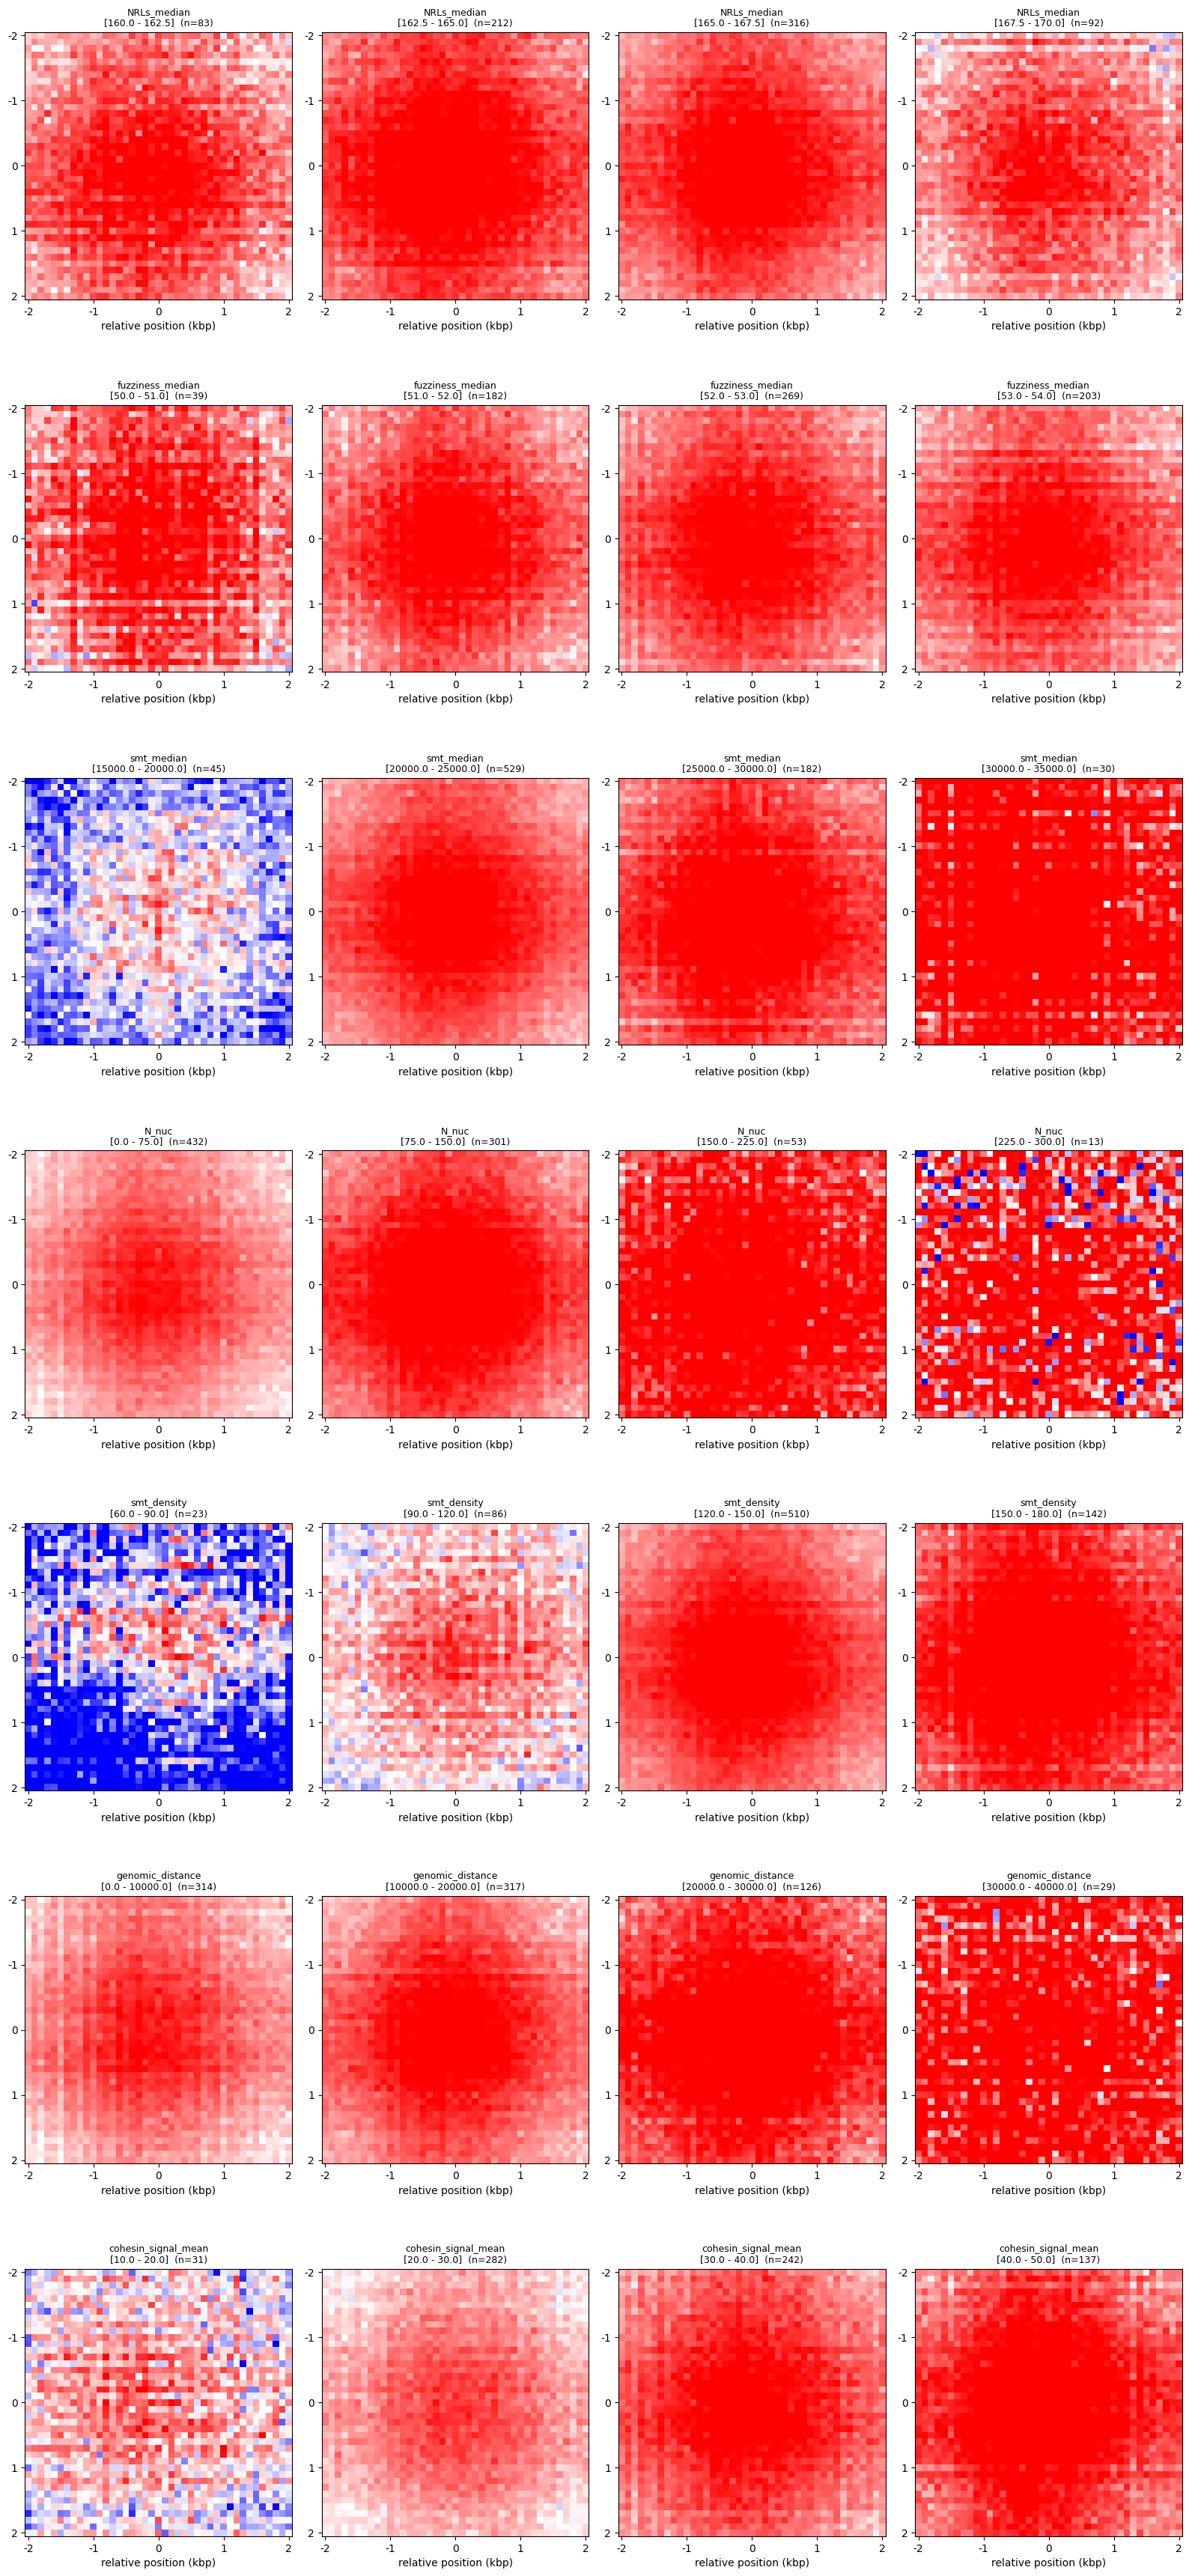

In [44]:
# ── Final Call ───────────────────────────────────────────────────────────

QUARTERS = [0, 1, 2, 3, 4]
COLUMNS = [
    "NRLs_median", "fuzziness_median", "smt_median", 
    "N_nuc", "smt_density", "genomic_distance", "cohesin_signal_mean"
] 

fig, axes = plt.subplots(
    figsize=(16, 5 * len(COLUMNS)),
    ncols=len(QUARTERS)-1,
    nrows=len(COLUMNS)
)

axes = np.atleast_2d(axes)

for i, value in enumerate(COLUMNS): 
    
    for j, quarter in enumerate(QUARTERS[:-1]):

        ax = axes[i, j]

        vmin = df_metric[value][quarter]
        vmax = df_metric[value][quarter + 1]

        df_single = filter_DataFrame_by_values(
            df_data=df_CARs_NUCLEO,
            key=value,
            vmin=vmin,
            vmax=vmax
        )

        dist = df_single["genomic_distance"].to_numpy()
        dist = dist[np.isfinite(dist)]

        show_hic(
            df_single,
            CLR,
            flank=FLANK,
            resolution=RESOLUTION,
            ax=ax
        )

        ax.set_title(f"{value}\n[{vmin:.1f} - {vmax:.1f}]  (n={len(dist)})", fontsize=9)

plt.tight_layout()
plt.savefig("HiC_Maps.png", dpi=300)
plt.show()

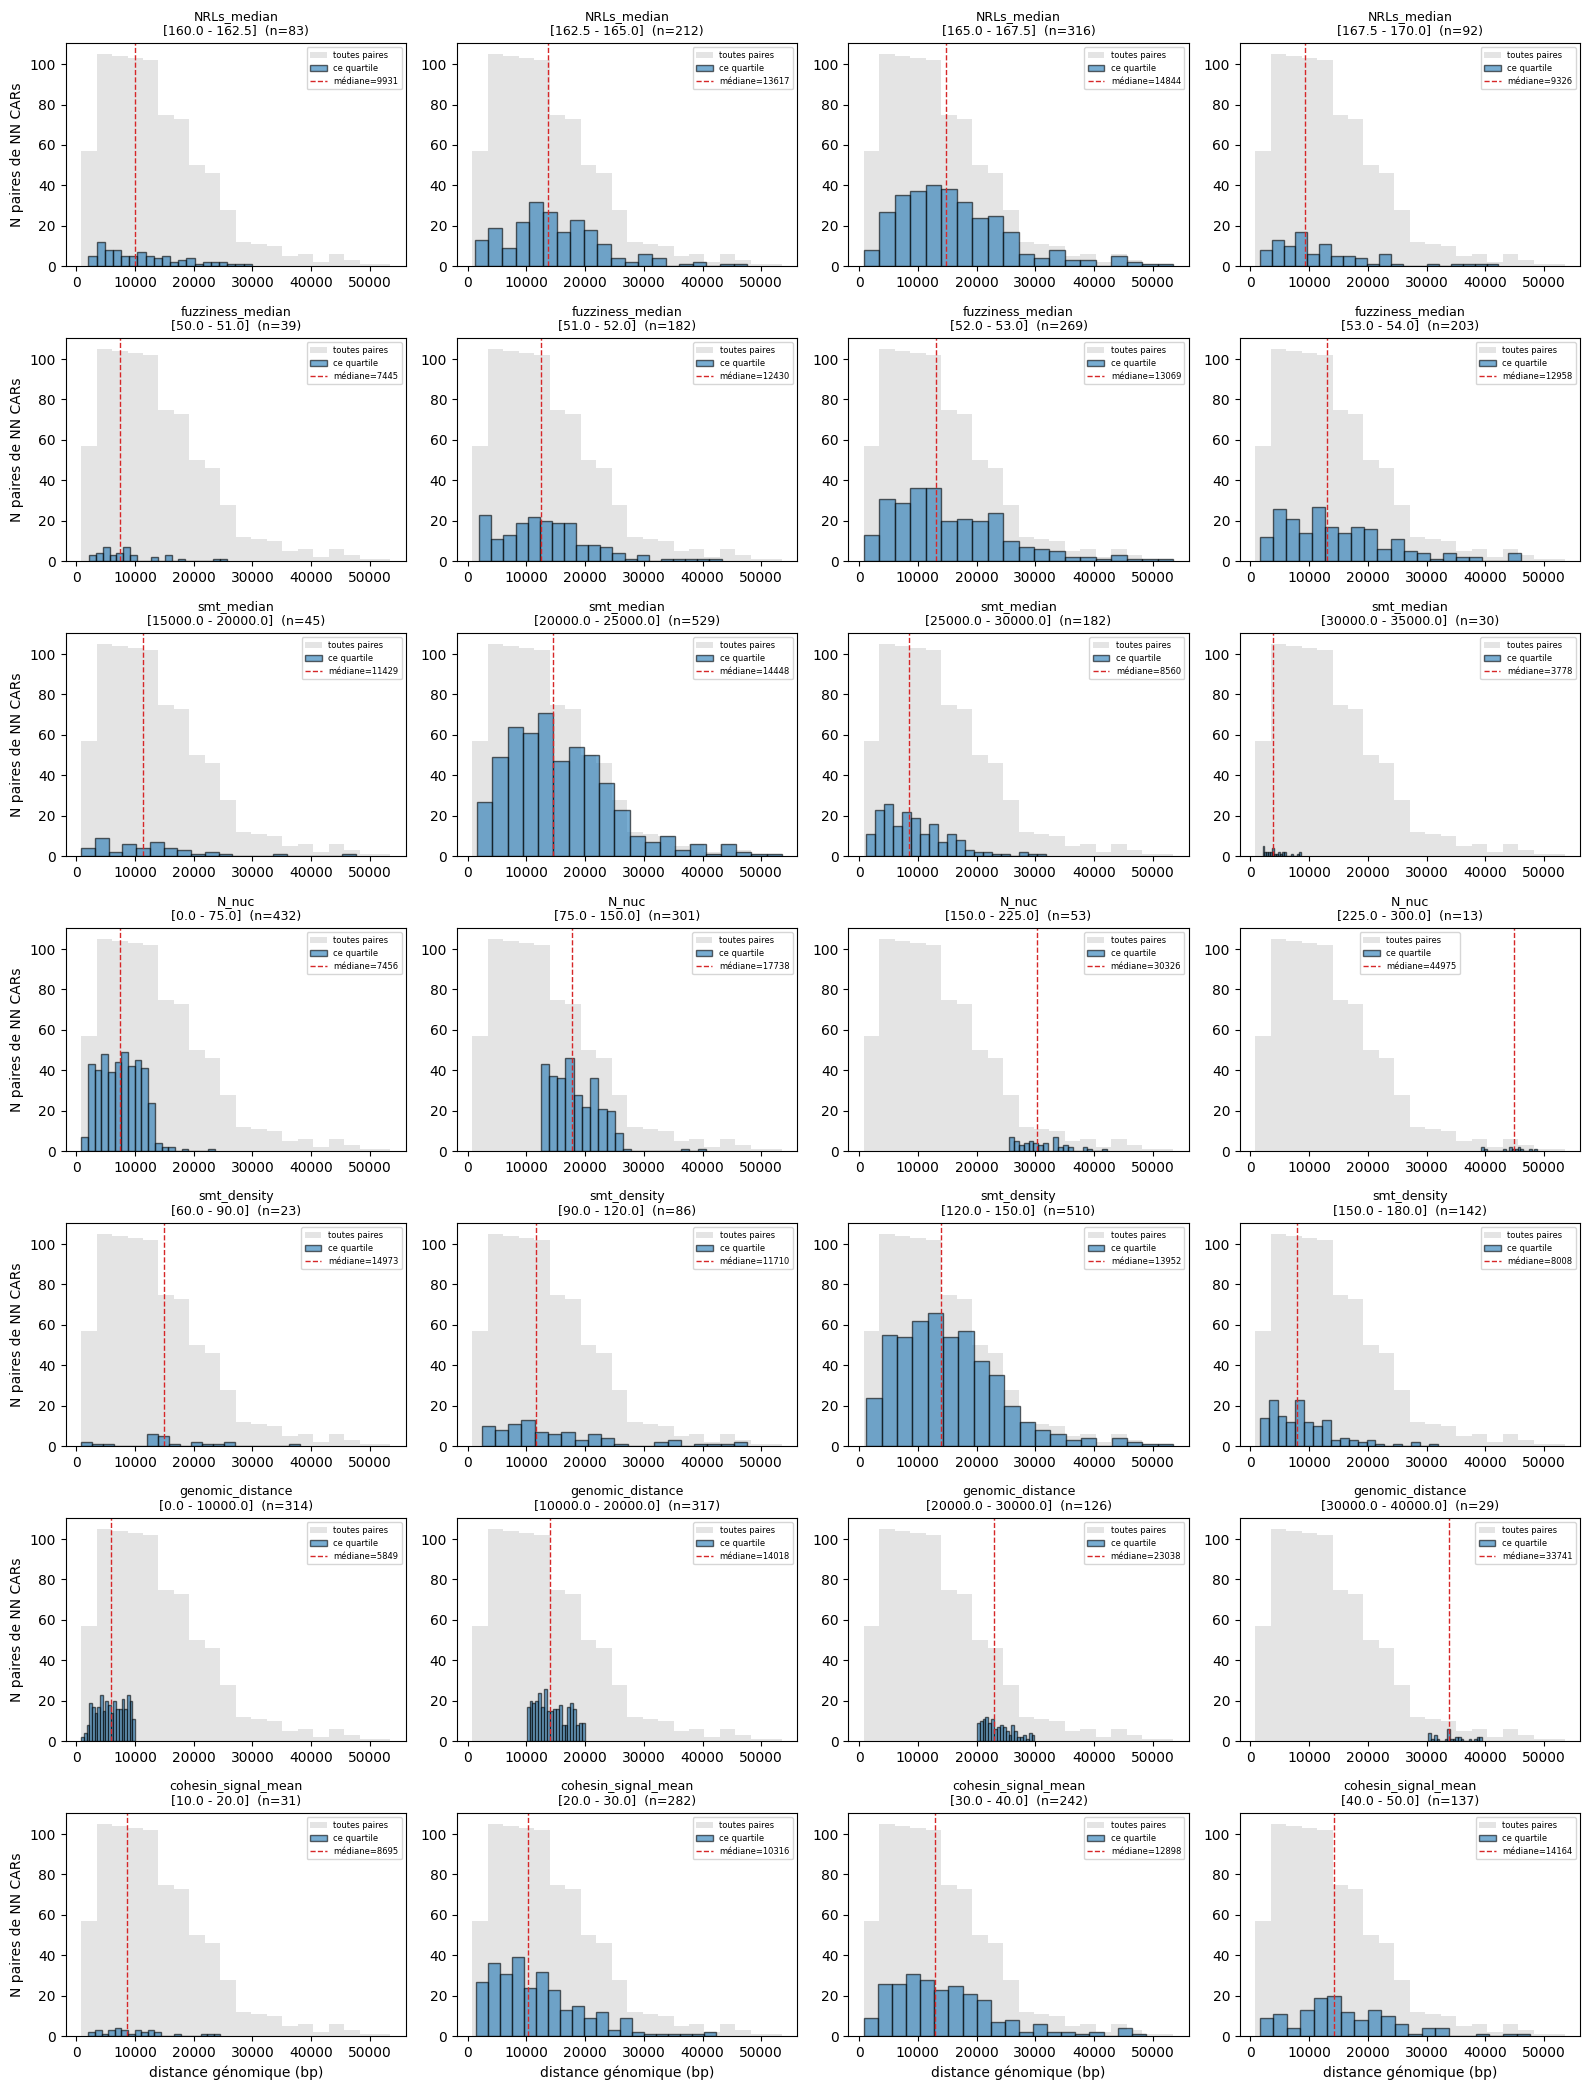

In [45]:
# ── Genomic distance distribution for each (COLUMNS, quartile) group ────
# Objective: for every panel of the Hi-C grid above ("Final Call" cell), show
# the distribution of genomic distances of the NN CARs pairs that went into
# it. This uses the *exact same* COLUMNS / QUARTERS / df_metric grouping as
# the Hi-C grid, so each histogram here corresponds one-to-one to the panel
# at the same (row, column) position above.
#
# Why this matters: if the blue histogram shifts noticeably from one
# quartile to the next (or relative to the grey "all pairs" reference), the
# groups built on NRL / fuzziness / smt / ... are also, incidentally, groups
# with different genomic distances. In that case, the Hi-C maps above would
# partly reflect a distance effect rather than an effect specific to the
# variable under study.

fig, axes = plt.subplots(
    figsize=(16, 3 * len(COLUMNS)),
    ncols=len(QUARTERS) - 1,
    nrows=len(COLUMNS),
    sharex=False,
)
axes = np.atleast_2d(axes)

# overall genomic distance (reference, shown in grey, on every subplot)
dist_all = df_CARs_NUCLEO["genomic_distance"].to_numpy()
dist_all = dist_all[np.isfinite(dist_all)]

for i, value in enumerate(COLUMNS):

    for j, quarter in enumerate(QUARTERS[:-1]):
        ax = axes[i, j]

        vmin = df_metric[value][quarter]
        vmax = df_metric[value][quarter + 1]

        df_single = filter_DataFrame_by_values(
            df_data=df_CARs_NUCLEO,
            key=value,
            vmin=vmin,
            vmax=vmax,
        )

        dist = df_single["genomic_distance"].to_numpy()
        dist = dist[np.isfinite(dist)]

        ax.hist(dist_all, bins=20, color="lightgray", alpha=0.6, label="toutes paires")
        ax.hist(dist, bins=20, edgecolor="black", color="tab:blue", alpha=0.6, label="ce quartile")
        ax.axvline(np.median(dist), color="tab:red", linestyle="--", linewidth=1,
                   label=f"médiane={np.median(dist):.0f}")

        ax.set_title(f"{value}\n[{vmin:.1f} - {vmax:.1f}]  (n={len(dist)})", fontsize=9)
        ax.legend(fontsize=6)

    axes[i, 0].set_ylabel("N paires de NN CARs")

for ax in axes[-1, :]:
    ax.set_xlabel("distance génomique (bp)")

plt.tight_layout()
plt.savefig("histograms_perinterval.png", dpi=300)
plt.show()

## Analysis over genomic distance

In [46]:
# ── Loop intensity between NN CARs (Hi-C observed/expected) ──────────────
# For each pair of NN CARs, we don't want the ChIP-seq (cohesin) signal
# around each individual CAR anymore. What we want is the intensity of the
# Hi-C LOOP formed BETWEEN CAR1 and CAR2: i.e. the observed/expected contact
# signal, averaged in a +/- 1 kb window centered on the (CAR1, CAR2) pixel
# of the Hi-C map (the "dot" between the two NN CARs).
#
# This reuses CLR (the cooler at RESOLUTION) and CVD (cooltools.expected_cis,
# computed with clr_weight_name=None) already loaded above.


import pandas as pd

FLANK_LOOP = 1_000  # +/- 1 kb around the CAR1-CAR2 contact (same convention as cohesin_signal_mean)


def build_expected_lookup(cvd: pd.DataFrame, expected_col: str = "count.avg.smoothed") -> dict:
    """Build, for each chromosome (view region), a 1D array giving the expected
    (average) Hi-C count as a function of the genomic distance in bins.
    lookup[chrom][d] = expected count for a pair of loci d bins apart on chrom.
    """
    region_col = "region1" if "region1" in cvd.columns else "region"
    lookup = {}
    for chrom, sub in cvd.groupby(region_col):
        sub = sub.sort_values("dist")
        dist = sub["dist"].to_numpy().astype(int)
        vals = sub[expected_col].to_numpy()
        arr = np.full(dist.max() + 1, np.nan)
        arr[dist] = vals
        lookup[chrom] = arr
    return lookup


def loop_oe_intensity(
    clr: "cooler.Cooler",
    expected_lookup: dict,
    chrom: str,
    pos1: float,
    pos2: float,
    resolution: int = RESOLUTION,
    flank_bp: int = FLANK_LOOP,
) -> float:
    """Mean observed/expected Hi-C signal in a +/- flank_bp window centered on
    the (pos1, pos2) contact point between two NN CARs (the loop intensity)."""

    if chrom not in clr.chromnames or chrom not in expected_lookup:
        return np.nan

    chrom_len = clr.chromsizes[chrom]
    r1_start, r1_end = max(0, int(pos1 - flank_bp)), min(int(chrom_len), int(pos1 + flank_bp))
    r2_start, r2_end = max(0, int(pos2 - flank_bp)), min(int(chrom_len), int(pos2 + flank_bp))
    if r1_end <= r1_start or r2_end <= r2_start:
        return np.nan

    region1 = f"{chrom}:{r1_start}-{r1_end}"
    region2 = f"{chrom}:{r2_start}-{r2_end}"

    mat = clr.matrix(balance=False).fetch(region1, region2)
    if mat.size == 0:
        return np.nan

    rows_pos = clr.bins().fetch(region1)["start"].to_numpy()
    cols_pos = clr.bins().fetch(region2)["start"].to_numpy()
    dist_bp = np.abs(rows_pos[:, None] - cols_pos[None, :])
    dist_bins = np.rint(dist_bp / resolution).astype(int)

    exp_arr = expected_lookup[chrom]
    dist_bins_clipped = np.clip(dist_bins, 0, len(exp_arr) - 1)
    expected = exp_arr[dist_bins_clipped]

    with np.errstate(divide="ignore", invalid="ignore"):
        oe = mat / expected

    return np.nanmean(oe)


EXPECTED_LOOKUP = build_expected_lookup(CVD, expected_col="count.avg.smoothed")

DF_CARS_NUCLEO["loop_oe_1kb"] = [
    loop_oe_intensity(CLR, EXPECTED_LOOKUP, chrom, p1, p2)
    for chrom, p1, p2 in zip(
        DF_CARS_NUCLEO["chrom1"], DF_CARS_NUCLEO["start1"], DF_CARS_NUCLEO["start2"]
    )
]

# Keep the parquet file and the polars dataframe used downstream in sync
DF_CARS_NUCLEO.to_parquet(PATH + "notebooks/cars/df_CARs_NUCLEO.parquet")
df_CARs_NUCLEO = pl.from_pandas(DF_CARS_NUCLEO)

print(
    df_CARs_NUCLEO
    .select(["chrom1", "start1", "start2", "genomic_distance", "loop_oe_1kb"])
    .head()
)


shape: (5, 5)
┌────────┬──────────┬──────────┬──────────────────┬─────────────┐
│ chrom1 ┆ start1   ┆ start2   ┆ genomic_distance ┆ loop_oe_1kb │
│ ---    ┆ ---      ┆ ---      ┆ ---              ┆ ---         │
│ str    ┆ f64      ┆ f64      ┆ f64              ┆ f64         │
╞════════╪══════════╪══════════╪══════════════════╪═════════════╡
│ chrI   ┆ 65253.0  ┆ 80364.0  ┆ 15111.0          ┆ 2.316349    │
│ chrI   ┆ 80364.0  ┆ 95296.0  ┆ 14932.0          ┆ 3.654558    │
│ chrI   ┆ 95296.0  ┆ 127193.0 ┆ 31897.0          ┆ 5.312162    │
│ chrI   ┆ 127193.0 ┆ 134169.0 ┆ 6976.0           ┆ 2.695965    │
│ chrI   ┆ 134169.0 ┆ 137151.0 ┆ 2982.0           ┆ 2.133935    │
└────────┴──────────┴──────────┴──────────────────┴─────────────┘


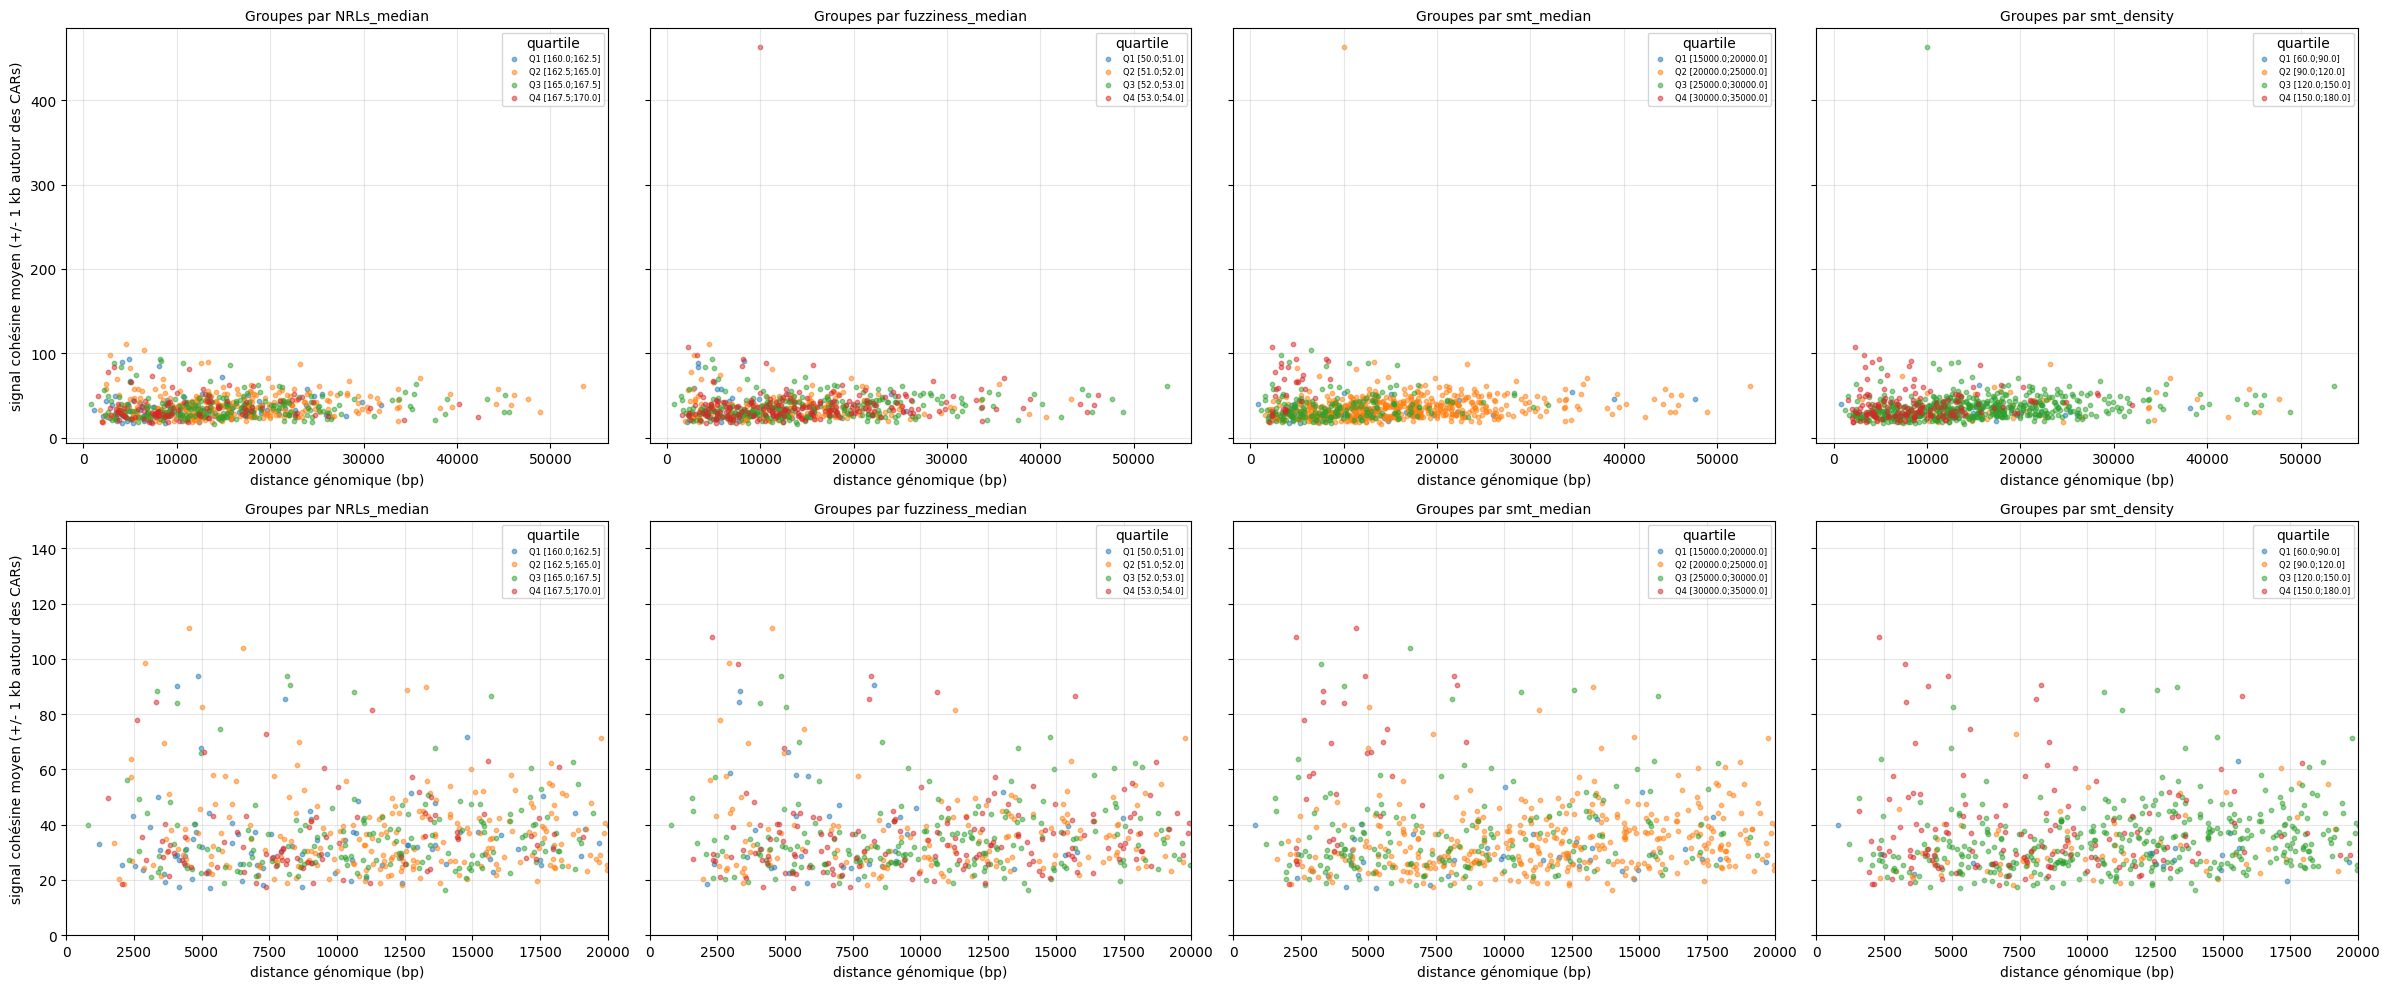

In [47]:
# ── Scatter plot: cohesin signal around CARs vs genomic distance ────
# For each pair of NN CARs, cohesin_signal_mean is already the mean of the
# cohesin signal within the +/- 1 kb window around CAR1 and CAR2 (calculated in the cell
# ‘Analyzing CARs_nn and Nucleosome profiles in parallel’, step 7).

COLUMNS_GROUP = ["NRLs_median", "fuzziness_median", "smt_median", "smt_density"]

pdf_all = df_CARs_NUCLEO.to_pandas()

fig, axes = plt.subplots(
    figsize=(6 * len(COLUMNS_GROUP), 10),
    ncols=len(COLUMNS_GROUP),
    nrows=2,
    # sharex=True,
    sharey="row",
)

for j, col in enumerate(COLUMNS_GROUP):

    bounds = df_metric[col].to_numpy()
    labels = [f"Q{k + 1} [{bounds[k]:.1f};{bounds[k+1]:.1f}]" for k in range(len(bounds) - 1)]

    group = pd.cut(pdf_all[col], bins=bounds, labels=labels, include_lowest=True)

    for i in range(2):

        ax = axes[i, j]

        for lab in labels:
            mask = (group == lab).to_numpy()
            ax.scatter(
                pdf_all.loc[mask, "genomic_distance"],
                pdf_all.loc[mask, "cohesin_signal_mean"],
                s=10,
                alpha=0.5,
                label=lab,
            )

        ax.set_xlabel("distance génomique (bp)")
        ax.set_title(f"Groupes par {col}", fontsize=10)
        ax.grid(True, alpha=0.3)

        if i == 1:
            ax.set_xlim(0, 20_000)
            ax.set_ylim(0, 150)

        ax.legend(fontsize=6, title="quartile")

axes[0, 0].set_ylabel("signal cohésine moyen (+/- 1 kb autour des CARs)")
axes[1, 0].set_ylabel("signal cohésine moyen (+/- 1 kb autour des CARs)")

plt.tight_layout()
plt.savefig("scatter_cohesin_signal_vs_genomic_distance.png", dpi=300)
plt.show()

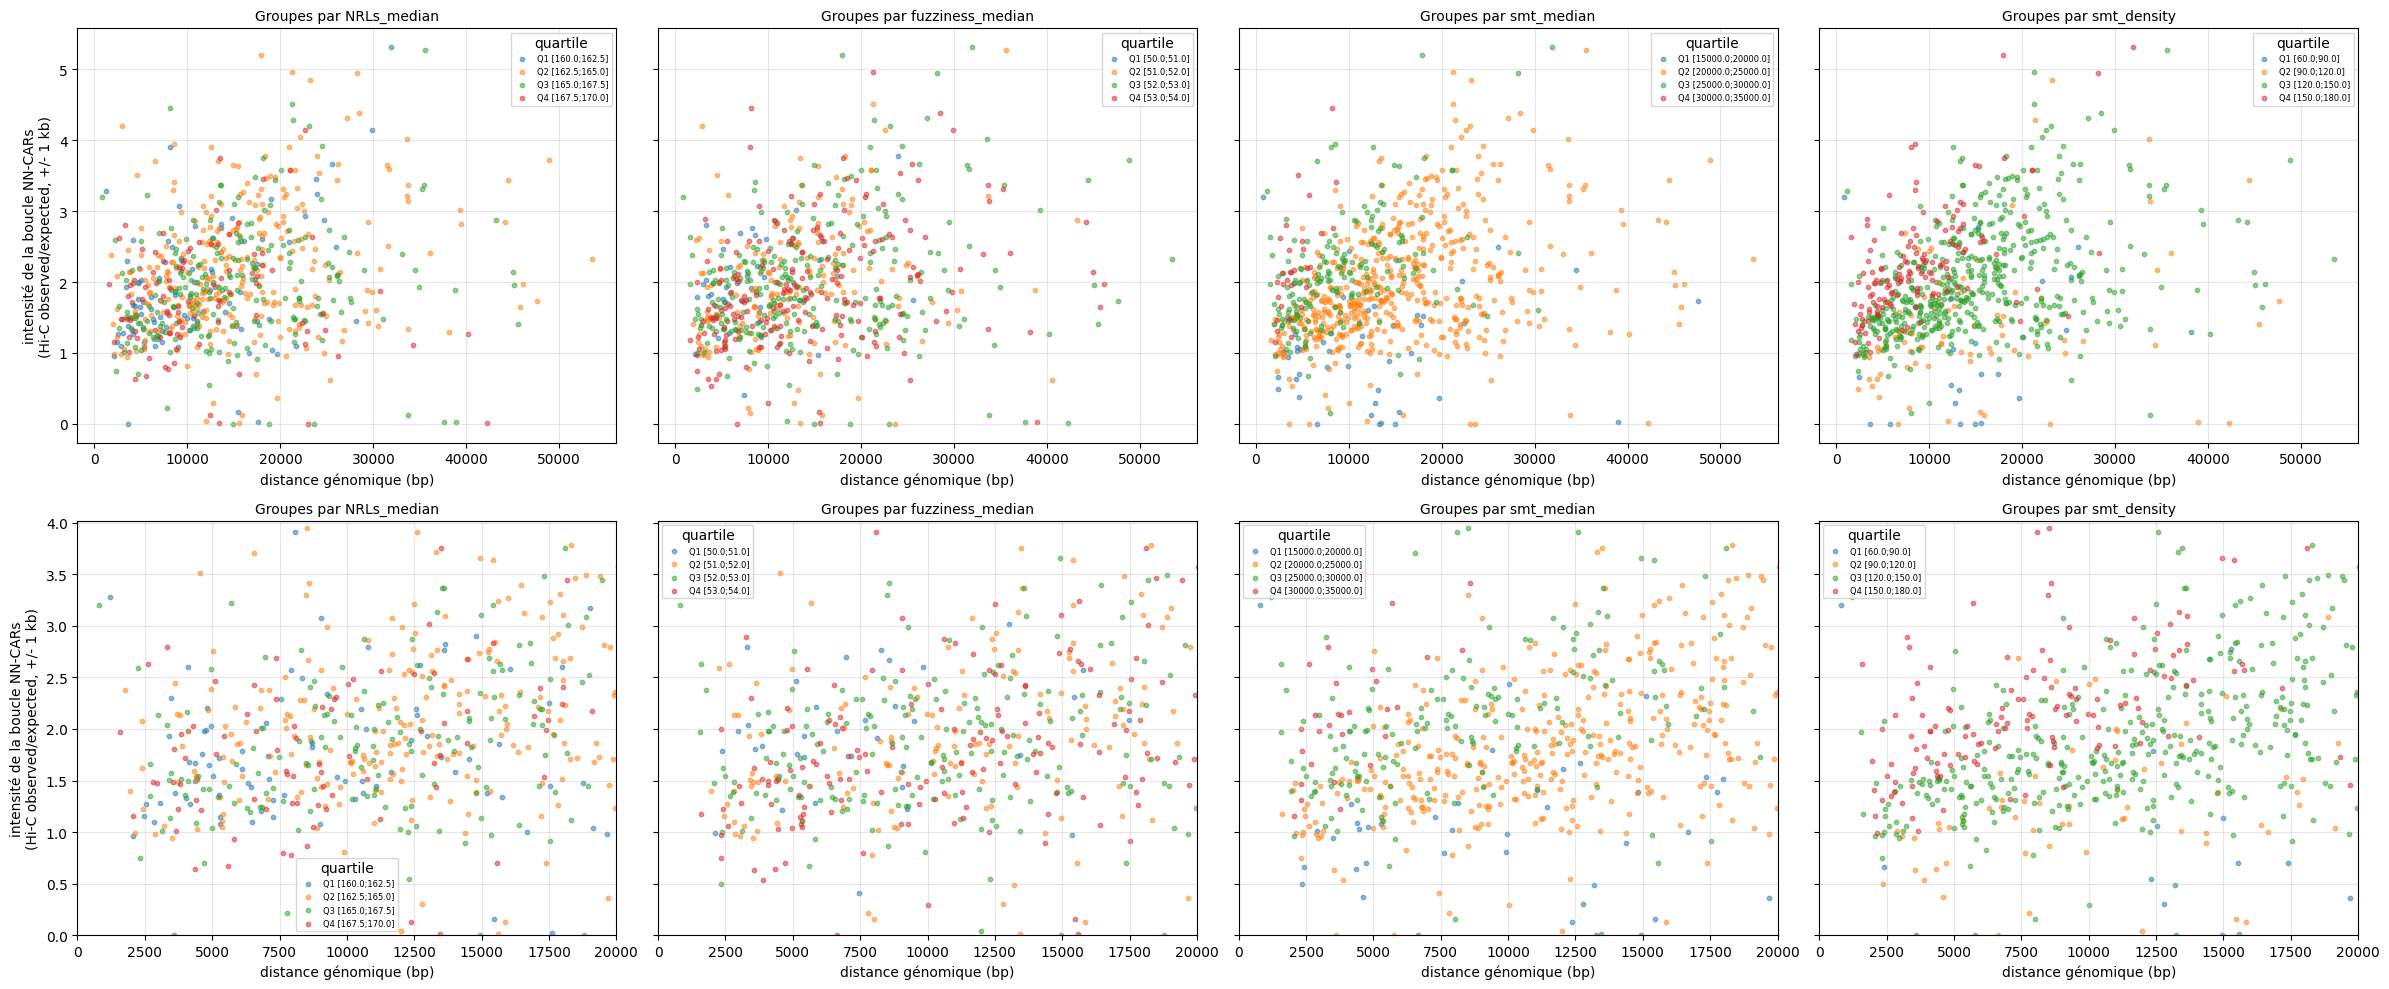

In [48]:
# ── Scatter plot: NN-CARs loop intensity (Hi-C O/E) vs genomic distance ────
# For each pair of NN CARs, loop_oe_1kb is the mean Hi-C observed/expected
# signal in the +/- 1 kb window centered on the (CAR1, CAR2) contact pixel,
# i.e. the intensity of the loop between the two NN CARs (calculated in the
# cell "Loop intensity between NN CARs (Hi-C observed/expected)" above).

COLUMNS_GROUP = ["NRLs_median", "fuzziness_median", "smt_median", "smt_density"]

pdf_all = df_CARs_NUCLEO.to_pandas()

y_col = "loop_oe_1kb"
y_zoom_max = np.nanpercentile(pdf_all[y_col].to_numpy(), 98)

fig, axes = plt.subplots(
    figsize=(6 * len(COLUMNS_GROUP), 10),
    ncols=len(COLUMNS_GROUP),
    nrows=2,
    # sharex=True,
    sharey="row",
)

for j, col in enumerate(COLUMNS_GROUP):

    bounds = df_metric[col].to_numpy()
    labels = [f"Q{k + 1} [{bounds[k]:.1f};{bounds[k+1]:.1f}]" for k in range(len(bounds) - 1)]

    group = pd.cut(pdf_all[col], bins=bounds, labels=labels, include_lowest=True)

    for i in range(2):

        ax = axes[i, j]

        for lab in labels:
            mask = (group == lab).to_numpy()
            ax.scatter(
                pdf_all.loc[mask, "genomic_distance"],
                pdf_all.loc[mask, y_col],
                s=10,
                alpha=0.5,
                label=lab,
            )

        ax.set_xlabel("distance génomique (bp)")
        ax.set_title(f"Groupes par {col}", fontsize=10)
        ax.grid(True, alpha=0.3)

        if i == 1:
            ax.set_xlim(0, 20_000)
            ax.set_ylim(0, y_zoom_max)

        ax.legend(fontsize=6, title="quartile")

axes[0, 0].set_ylabel("intensité de la boucle NN-CARs\n(Hi-C observed/expected, +/- 1 kb)")
axes[1, 0].set_ylabel("intensité de la boucle NN-CARs\n(Hi-C observed/expected, +/- 1 kb)")

plt.tight_layout()
plt.savefig("scatter_loop_oe_vs_genomic_distance.png", dpi=300)
plt.show()


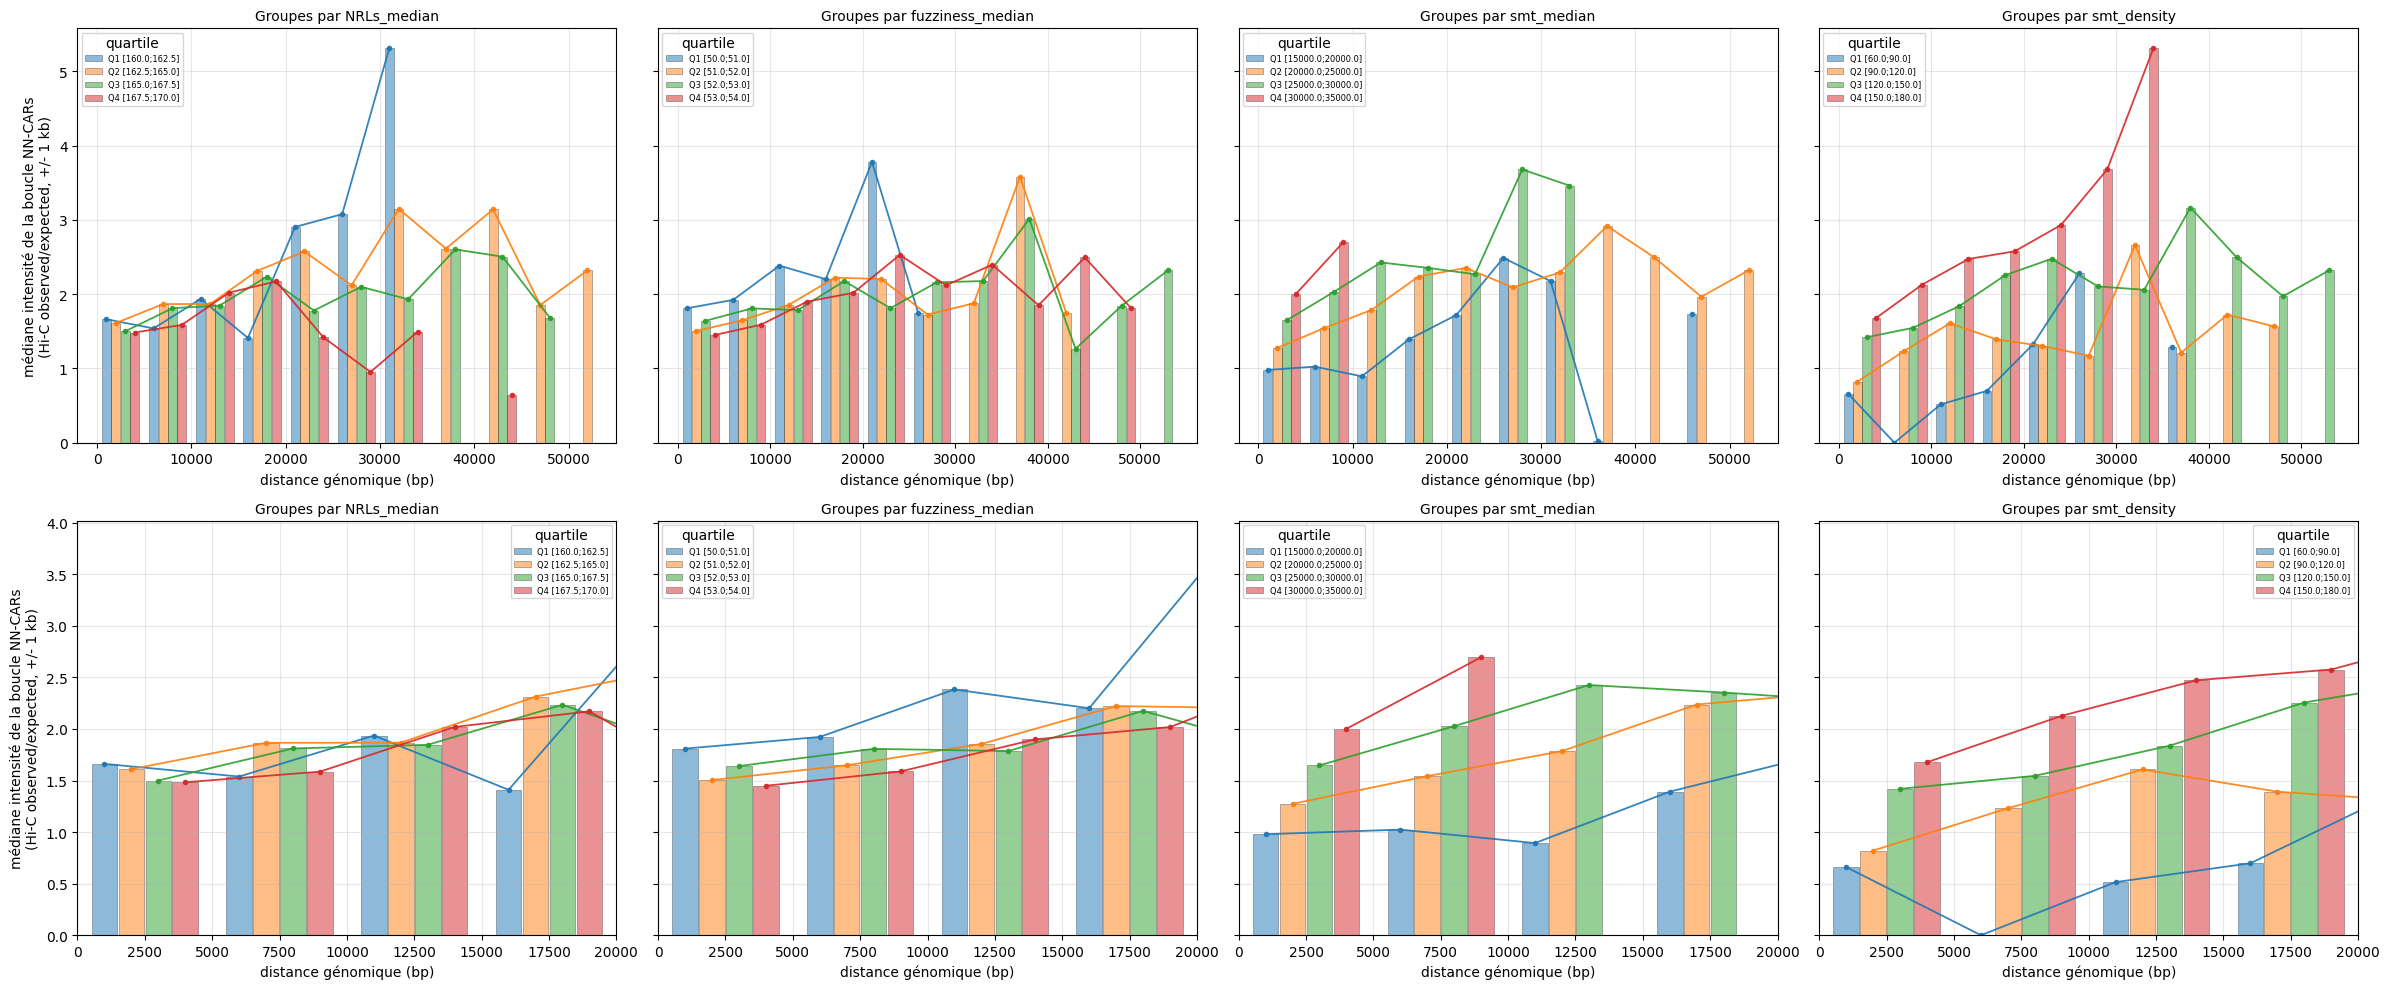

In [55]:
# ── Binned median plot (histogramme classique + médiane par-dessus) ────
COLUMNS_GROUP = ["NRLs_median", "fuzziness_median", "smt_median", "smt_density"]
pdf_all = df_CARs_NUCLEO.to_pandas()
y_col = "loop_oe_1kb"
BIN_SIZE = 5000

y_zoom_max = np.nanpercentile(pdf_all[y_col].to_numpy(), 98)

# bins communs sur la distance génomique (0 -> max, pas de 5000)
dist_max = pdf_all["genomic_distance"].max()
dist_bins = np.arange(0, dist_max + BIN_SIZE, BIN_SIZE)
bin_centers = (dist_bins[:-1] + dist_bins[1:]) / 2

fig, axes = plt.subplots(
    figsize=(6 * len(COLUMNS_GROUP), 10),
    ncols=len(COLUMNS_GROUP),
    nrows=2,
    sharey="row",
)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for j, col in enumerate(COLUMNS_GROUP):
    bounds = df_metric[col].to_numpy()
    labels = [f"Q{k + 1} [{bounds[k]:.1f};{bounds[k+1]:.1f}]" for k in range(len(bounds) - 1)]
    group = pd.cut(pdf_all[col], bins=bounds, labels=labels, include_lowest=True)
    n_q = len(labels)
    bar_width = BIN_SIZE / (n_q + 1)  # laisse un peu d'air entre les groupes

    dist_group = pd.cut(pdf_all["genomic_distance"], bins=dist_bins, labels=False, include_lowest=True)

    for i in range(2):
        ax = axes[i, j]
        for k, lab in enumerate(labels):
            mask = (group == lab).to_numpy()
            sub = pd.DataFrame({
                y_col: pdf_all.loc[mask, y_col].to_numpy(),
                "bin_idx": dist_group[mask],
            })
            medians = sub.groupby("bin_idx")[y_col].median().reindex(range(len(dist_bins) - 1))
            offset = (k - (n_q - 1) / 2) * bar_width
            color = colors[k % len(colors)]

            # barres classiques : edgecolor, alpha
            ax.bar(
                bin_centers + offset,
                medians.to_numpy(),
                width=bar_width * 0.95,
                color=color,
                edgecolor="black",
                linewidth=0.4,
                alpha=0.5,
                label=lab,
            )
            # médiane tracée par-dessus
            ax.plot(
                bin_centers + offset,
                medians.to_numpy(),
                color=color,
                marker="o",
                markersize=3,
                linewidth=1.3,
                alpha=0.9,
            )
        ax.set_xlabel("distance génomique (bp)")
        ax.set_title(f"Groupes par {col}", fontsize=10)
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.set_xlim(0, 20_000)
            ax.set_ylim(0, y_zoom_max)
        ax.legend(fontsize=6, title="quartile")
axes[0, 0].set_ylabel("médiane intensité de la boucle NN-CARs\n(Hi-C observed/expected, +/- 1 kb)")
axes[1, 0].set_ylabel("médiane intensité de la boucle NN-CARs\n(Hi-C observed/expected, +/- 1 kb)")
plt.tight_layout()
plt.savefig("bar_median_loop_oe_vs_genomic_distance.png", dpi=300)
plt.show()

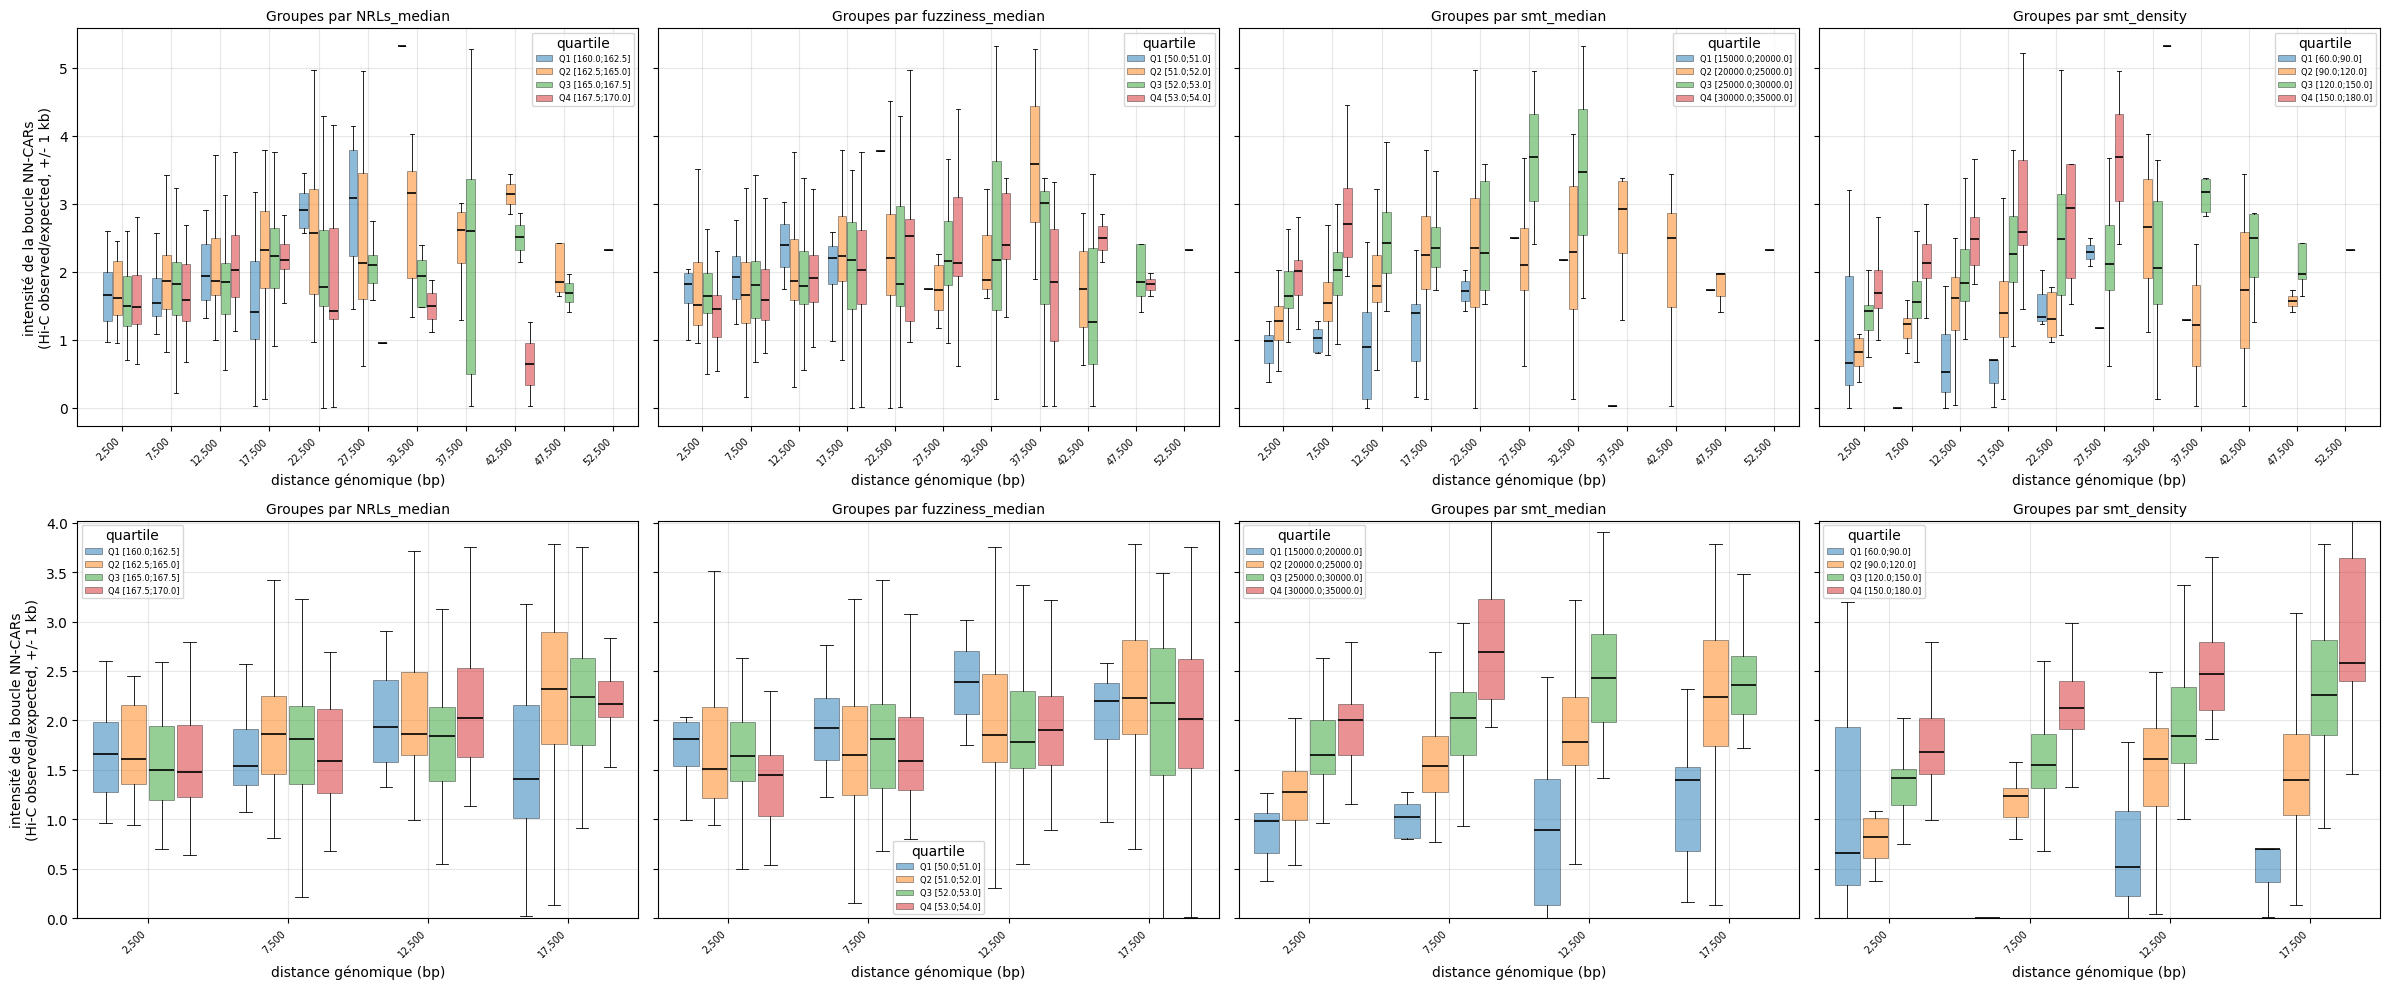

In [58]:
# ── Binned boxplots: NN-CARs loop intensity distribution vs genomic distance ────
from matplotlib.ticker import MaxNLocator

COLUMNS_GROUP = ["NRLs_median", "fuzziness_median", "smt_median", "smt_density"]
pdf_all = df_CARs_NUCLEO.to_pandas()
y_col = "loop_oe_1kb"
BIN_SIZE = 5000

y_zoom_max = np.nanpercentile(pdf_all[y_col].to_numpy(), 98)

dist_max = pdf_all["genomic_distance"].max()
dist_bins = np.arange(0, dist_max + BIN_SIZE, BIN_SIZE)
bin_centers = (dist_bins[:-1] + dist_bins[1:]) / 2

fig, axes = plt.subplots(
    figsize=(6 * len(COLUMNS_GROUP), 10),
    ncols=len(COLUMNS_GROUP),
    nrows=2,
    sharey="row",
)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for j, col in enumerate(COLUMNS_GROUP):
    bounds = df_metric[col].to_numpy()
    labels = [f"Q{k + 1} [{bounds[k]:.1f};{bounds[k+1]:.1f}]" for k in range(len(bounds) - 1)]
    group = pd.cut(pdf_all[col], bins=bounds, labels=labels, include_lowest=True)
    n_q = len(labels)
    box_width = BIN_SIZE / (n_q + 1)

    dist_group = pd.cut(pdf_all["genomic_distance"], bins=dist_bins, labels=False, include_lowest=True)

    for i in range(2):
        ax = axes[i, j]
        if i == 1:
            visible_bin_idx = np.where(dist_bins[:-1] < 20_000)[0]
        else:
            visible_bin_idx = np.arange(len(dist_bins) - 1)

        for k, lab in enumerate(labels):
            mask = (group == lab).to_numpy()
            sub = pd.DataFrame({
                y_col: pdf_all.loc[mask, y_col].to_numpy(),
                "bin_idx": dist_group[mask],
            })
            offset = (k - (n_q - 1) / 2) * box_width
            color = colors[k % len(colors)]

            data_per_bin = []
            positions = []
            for b in visible_bin_idx:
                vals = sub.loc[sub["bin_idx"] == b, y_col].dropna().to_numpy()
                if len(vals) > 0:
                    data_per_bin.append(vals)
                    positions.append(bin_centers[b] + offset)

            if not data_per_bin:
                continue

            bp = ax.boxplot(
                data_per_bin,
                positions=positions,
                widths=box_width * 0.9,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor=color, edgecolor="black", alpha=0.5, linewidth=0.5),
                medianprops=dict(color="black", linewidth=1.2),
                whiskerprops=dict(color="black", linewidth=0.6),
                capprops=dict(color="black", linewidth=0.6),
            )
            bp["boxes"][0].set_label(lab)

        # ── fix des ticks x : un tick tous les N bins (sous-échantillonnage), rotation ──
        MAX_TICKS = 15
        vis_centers = bin_centers[visible_bin_idx]
        step = max(1, len(vis_centers) // MAX_TICKS)
        tick_positions = vis_centers[::step]

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(
            [f"{int(c):,}" for c in tick_positions],
            rotation=45,
            ha="right",
            fontsize=7,
        )

        ax.set_xlabel("distance génomique (bp)")
        ax.set_title(f"Groupes par {col}", fontsize=10)
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.set_xlim(0, 20_000)
            ax.set_ylim(0, y_zoom_max)
        ax.legend(fontsize=6, title="quartile")
axes[0, 0].set_ylabel("intensité de la boucle NN-CARs\n(Hi-C observed/expected, +/- 1 kb)")
axes[1, 0].set_ylabel("intensité de la boucle NN-CARs\n(Hi-C observed/expected, +/- 1 kb)")
plt.tight_layout()
plt.savefig("boxplot_loop_oe_vs_genomic_distance.png", dpi=300)
plt.show()

# .